# Results Aggregation & Visualization

**CS 1675 - Introduction to Machine Learning**

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Color scheme - clean, professional
COLORS = ['#2C3E50', '#E74C3C', '#18BC9C']  # Charcoal, Coral red, Teal
MODELS = ['Logistic Regression', 'Random Forest', 'Neural Network']

print("Libraries loaded")

Libraries loaded


## 1. Baseline Performance

Performance metrics for all 3 models trained on the full feature set.

In [3]:
# Load baseline performance
performance = pd.read_csv('results/baseline/performance.csv', index_col=0)
performance

,Accuracy,Precision,Recall,F1,FPR,ROC-AUC
Logistic Regression,0.733835,0.343667,0.760236,0.473353,0.271094,0.820937
Random Forest,0.778399,0.381479,0.657287,0.482767,0.198987,0.816597
Neural Network,0.735452,0.346516,0.769166,0.477785,0.270843,0.826258


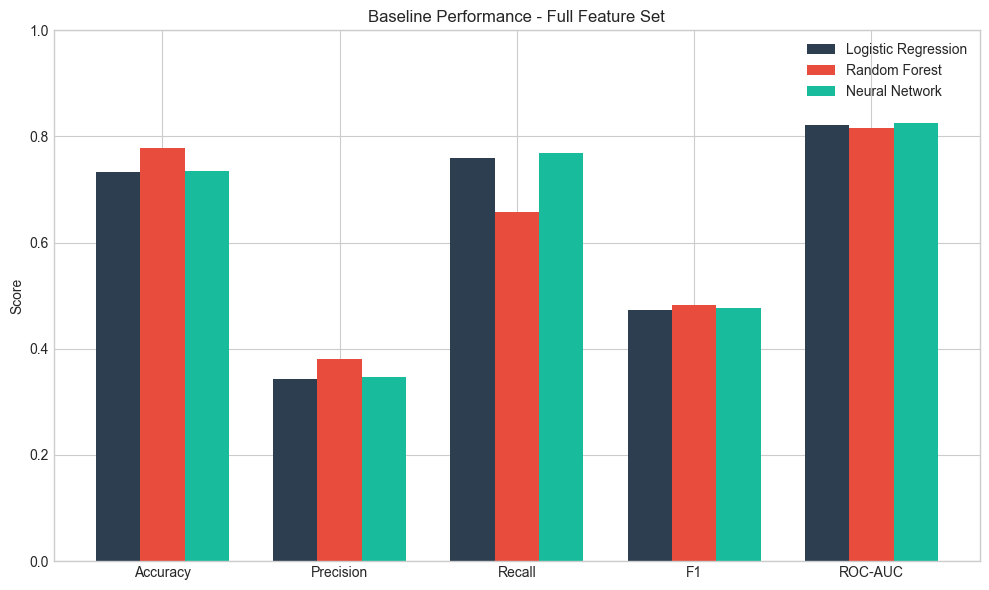

In [4]:
# Bar chart of key metrics by model
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(MODELS):
    values = performance.loc[model, metrics]
    ax.bar(x + i*width, values, width, label=model, color=COLORS[i])

ax.set_ylabel('Score')
ax.set_title('Baseline Performance - Full Feature Set')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 2. Baseline Fairness

How fair is each model across demographic groups (Race, Sex, Age)?

In [5]:
# Load baseline fairness data
def load_fairness(demo, model_short):
    df = pd.read_csv(f'results/baseline/fairness_{demo}_{model_short}.csv', index_col=0)
    return df

# Compute disparity gaps for each model and demographic
def get_gaps(demo, model_short):
    df = load_fairness(demo, model_short)
    return {
        'Recall Gap': df['Recall'].max() - df['Recall'].min(),
        'FPR Gap': df['FPR'].max() - df['FPR'].min(),
        'Precision Gap': df['Precision'].max() - df['Precision'].min()
    }

# Build summary table
rows = []
for demo in ['race', 'sex', 'age']:
    for model_short, model_name in [('LR', 'Logistic Regression'), ('RF', 'Random Forest'), ('NN', 'Neural Network')]:
        gaps = get_gaps(demo, model_short)
        gaps['Demographic'] = demo.capitalize()
        gaps['Model'] = model_name
        rows.append(gaps)

fairness_summary = pd.DataFrame(rows)
fairness_summary

,Recall Gap,FPR Gap,Precision Gap,Demographic,Model
0,0.256113,0.225871,0.140533,Race,Logistic Regression
1,0.329472,0.196231,0.195613,Race,Random Forest
2,0.204709,0.271797,0.202105,Race,Neural Network
3,0.019696,0.050960,0.005397,Sex,Logistic Regression
4,0.003734,0.026574,0.000455,Sex,Random Forest
5,0.010492,0.053840,0.010594,Sex,Neural Network
6,0.653711,0.621876,0.213787,Age,Logistic Regression
7,0.765799,0.398107,1.000000,Age,Random Forest
8,0.709483,0.518373,0.068877,Age,Neural Network


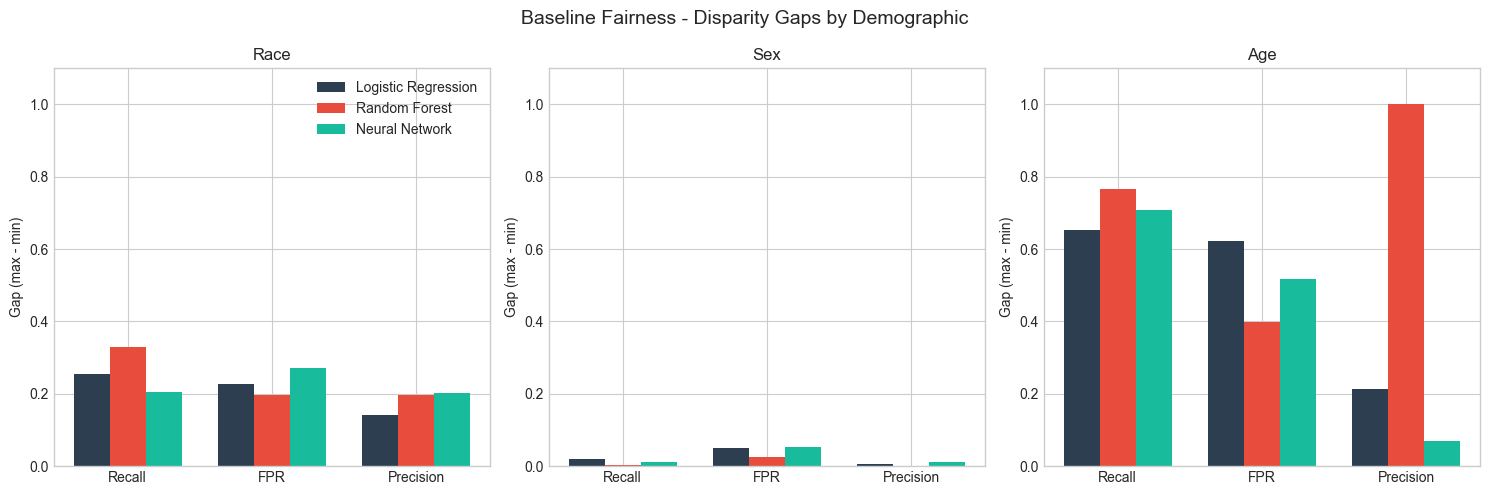

In [6]:
# Disparity gaps by demographic group - all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, demo in zip(axes, ['Race', 'Sex', 'Age']):
    demo_data = fairness_summary[fairness_summary['Demographic'] == demo]
    
    x = np.arange(3)  # 3 gap metrics
    width = 0.25
    
    for i, model in enumerate(MODELS):
        model_row = demo_data[demo_data['Model'] == model].iloc[0]
        values = [model_row['Recall Gap'], model_row['FPR Gap'], model_row['Precision Gap']]
        ax.bar(x + i*width, values, width, label=model, color=COLORS[i])
    
    ax.set_title(f'{demo}')
    ax.set_xticks(x + width)
    ax.set_xticklabels(['Recall', 'FPR', 'Precision'])
    ax.set_ylabel('Gap (max - min)')
    ax.set_ylim(0, 1.1)
    if demo == 'Race':
        ax.legend()

plt.suptitle('Baseline Fairness - Disparity Gaps by Demographic', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Overall Performance Across Configurations

F1 and ROC-AUC for all 3 models across the 5 feature configurations.

In [7]:
# Load performance from all 5 experiments
EXPERIMENTS = ['baseline', 'no_lifestyle', 'no_demographics', 'no_healthcare', 'health_only']
EXP_LABELS = ['Full Features', 'No Lifestyle', 'No Demographics', 'No Healthcare', 'Health Only']

all_performance = []
for exp, label in zip(EXPERIMENTS, EXP_LABELS):
    df = pd.read_csv(f'results/{exp}/performance.csv', index_col=0)
    df['Experiment'] = label
    all_performance.append(df)

all_perf = pd.concat(all_performance)
all_perf

,Accuracy,Precision,Recall,F1,FPR,ROC-AUC,Experiment
Logistic Regression,0.733835,0.343667,0.760236,0.473353,0.271094,0.820937,Full Features
Random Forest,0.778399,0.381479,0.657287,0.482767,0.198987,0.816597,Full Features
Neural Network,0.735452,0.346516,0.769166,0.477785,0.270843,0.826258,Full Features
Logistic Regression,0.734975,0.345387,0.764448,0.475801,0.270528,0.819692,No Lifestyle
Random Forest,0.773574,0.374470,0.654928,0.476494,0.204272,0.812775,No Lifestyle
Neural Network,0.730309,0.343014,0.780118,0.476509,0.278991,0.826264,No Lifestyle
Logistic Regression,0.728374,0.335496,0.740691,0.461813,0.273926,0.806006,No Demographics
Random Forest,0.741735,0.344396,0.709857,0.463782,0.252312,0.804031,No Demographics
Neural Network,0.714854,0.326570,0.764785,0.457699,0.294469,0.810168,No Demographics
Logistic Regression,0.733915,0.343817,0.760741,0.473593,0.271094,0.820984,No Healthcare


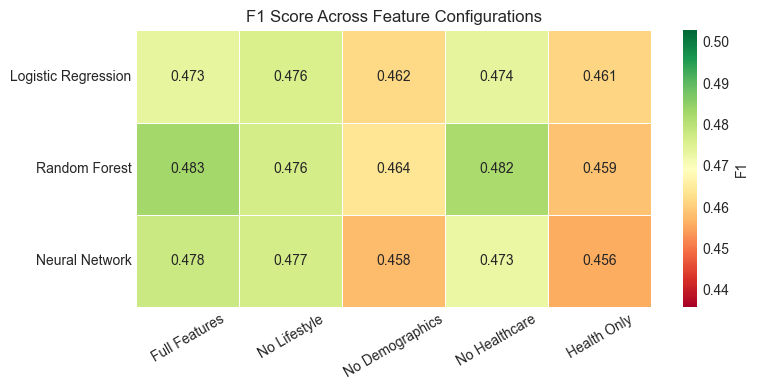

In [8]:
# Heatmap: F1 across models and configurations
fig, ax = plt.subplots(figsize=(8, 4))

pivot = all_perf.pivot_table(index=all_perf.index, columns='Experiment', values='F1')
pivot = pivot[EXP_LABELS].reindex(MODELS)

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            ax=ax, cbar_kws={'label': 'F1'},
            vmin=pivot.values.min() - 0.02, vmax=pivot.values.max() + 0.02,
            linewidths=0.5)
ax.set_title('F1 Score Across Feature Configurations')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

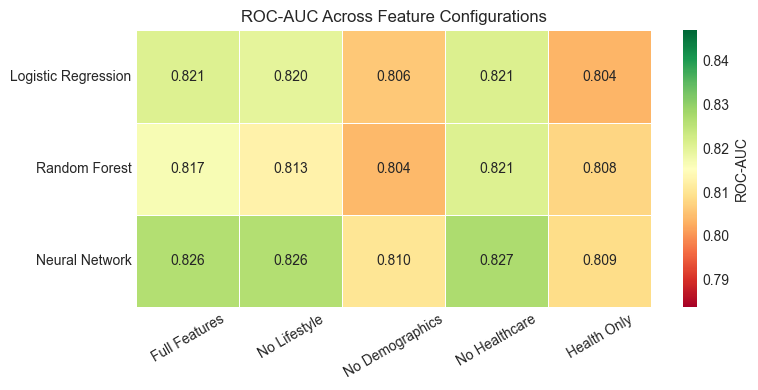

In [9]:
# Heatmap: ROC-AUC across models and configurations
fig, ax = plt.subplots(figsize=(8, 4))

pivot = all_perf.pivot_table(index=all_perf.index, columns='Experiment', values='ROC-AUC')
pivot = pivot[EXP_LABELS].reindex(MODELS)

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            ax=ax, cbar_kws={'label': 'ROC-AUC'},
            vmin=pivot.values.min() - 0.02, vmax=pivot.values.max() + 0.02,
            linewidths=0.5)
ax.set_title('ROC-AUC Across Feature Configurations')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Fairness Across Configurations

Fairness gaps (Recall, FPR, Precision) for each demographic group across all 5 feature configurations.

In [9]:
# Load fairness data from all experiments
def load_fairness_exp(exp, demo, model_short):
    df = pd.read_csv(f'results/{exp}/fairness_{demo}_{model_short}.csv', index_col=0)
    return df

def get_gaps_exp(exp, demo, model_short):
    df = load_fairness_exp(exp, demo, model_short)
    return {
        'Recall Gap': df['Recall'].max() - df['Recall'].min(),
        'FPR Gap': df['FPR'].max() - df['FPR'].min(),
        'Precision Gap': df['Precision'].max() - df['Precision'].min()
    }

# Build fairness data for all experiments
all_fairness = []
for exp, label in zip(EXPERIMENTS, EXP_LABELS):
    for demo in ['race', 'sex', 'age']:
        for model_short, model_name in [('LR', 'Logistic Regression'), ('RF', 'Random Forest'), ('NN', 'Neural Network')]:
            gaps = get_gaps_exp(exp, demo, model_short)
            gaps['Experiment'] = label
            gaps['Demographic'] = demo.capitalize()
            gaps['Model'] = model_name
            all_fairness.append(gaps)

all_fair_df = pd.DataFrame(all_fairness)
all_fair_df.head(9)

,Recall Gap,FPR Gap,Precision Gap,Experiment,Demographic,Model
0,0.256113,0.225871,0.140533,Full Features,Race,Logistic Regression
1,0.329472,0.196231,0.195613,Full Features,Race,Random Forest
2,0.204709,0.271797,0.202105,Full Features,Race,Neural Network
3,0.019696,0.050960,0.005397,Full Features,Sex,Logistic Regression
4,0.003734,0.026574,0.000455,Full Features,Sex,Random Forest
5,0.010492,0.053840,0.010594,Full Features,Sex,Neural Network
6,0.653711,0.621876,0.213787,Full Features,Age,Logistic Regression
7,0.765799,0.398107,1.000000,Full Features,Age,Random Forest
8,0.709483,0.518373,0.068877,Full Features,Age,Neural Network


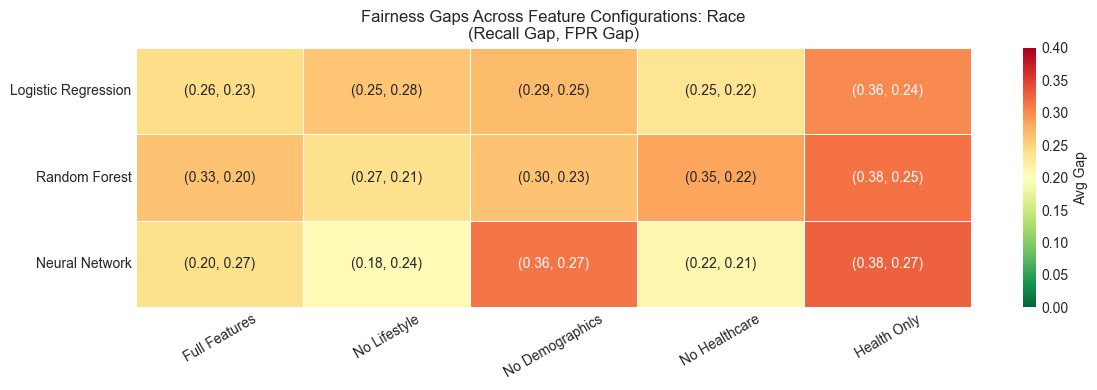

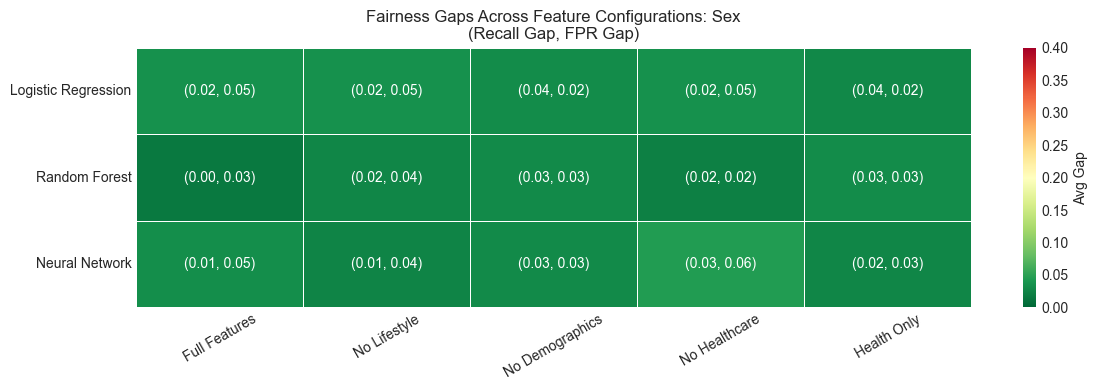

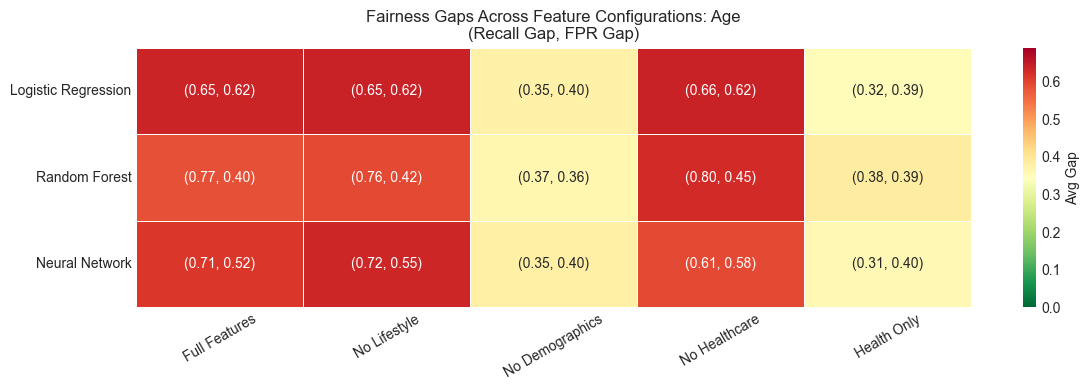

In [11]:
# Fairness heatmaps for each demographic group
# Color based on average of Recall Gap and FPR Gap; text shows (Recall, FPR)

for demo in ['Race', 'Sex', 'Age']:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    demo_data = all_fair_df[all_fair_df['Demographic'] == demo]
    
    # Pivot for each metric
    recall_pivot = demo_data.pivot_table(index='Model', columns='Experiment', values='Recall Gap')
    fpr_pivot = demo_data.pivot_table(index='Model', columns='Experiment', values='FPR Gap')
    
    # Reorder
    recall_pivot = recall_pivot[EXP_LABELS].reindex(MODELS)
    fpr_pivot = fpr_pivot[EXP_LABELS].reindex(MODELS)
    
    # Average for color
    avg_pivot = (recall_pivot + fpr_pivot) / 2
    
    # Create annotation text: (Recall, FPR)
    annot = np.empty_like(avg_pivot, dtype=object)
    for i in range(len(MODELS)):
        for j in range(len(EXP_LABELS)):
            annot[i, j] = f"({recall_pivot.iloc[i, j]:.2f}, {fpr_pivot.iloc[i, j]:.2f})"
    
    sns.heatmap(avg_pivot, annot=annot, fmt='', cmap='RdYlGn_r',
                ax=ax, cbar_kws={'label': 'Avg Gap'},
                vmin=0, vmax=max(0.4, avg_pivot.values.max() + 0.05),
                linewidths=0.5)
    ax.set_title(f'Fairness Gaps Across Feature Configurations: {demo}\n(Recall Gap, FPR Gap)', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()